# Projekt 1 Rating/Scoring z interpretowalnością, wyjaśnialnością i kalibracją

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss, 
                             brier_score_loss, roc_curve, precision_recall_curve, auc, confusion_matrix, precision_score, recall_score, f1_score)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay

from scipy.stats import ks_2samp

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

import shap

import seaborn as sns

## Praca z danymi

### Wczytanie danych i wstępne informacje

Wczytujemy dane zaczynamy pracę z nimi

In [2]:
Dane = pd.read_csv("C:\\Users\\karol\\OneDrive\\Pulpit\\interpretowalnośc\\zbiór_13.csv")
Dane.info()
print('Braki danych')
print((Dane.isna().mean() == 0).mean())
print('procent default')
print(Dane['default'].astype(int).mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Columns: 220 entries, szczegolnaFormaPrawna_Symbol to default
dtypes: float64(213), int64(5), object(2)
memory usage: 5.0+ MB
Braki danych
0.9545454545454546
procent default
0.14833333333333334


#### Usunięcie/zamina nieporządanych wartości
Zaczniemy od bazowego czyszczenia, czyli zamiany pustych miejsc, nieskonczoności na NaN

In [3]:
# Wczytanie danych i ich podział na X i y
df = Dane.copy()
X = df.drop('default', axis = 1).copy()
y = df['default'].astype(int)

# 1. Nieskończoności
X = X.replace([np.inf, -np.inf, 'inf', '-inf', '+inf'], np.nan)

# 2. puste znaki '' na NaN
X = X.replace(r"^\s*$", np.nan, regex=True)

# 3. Identyfikacja kolumn kategorycznych
kolumny_kategoryczne = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Znalezione kolumny kategoryczne:", kolumny_kategoryczne)

# 4. Rzutowanie pozostałych kolumn na typ numeryczny
num_like_cols = [c for c in X.columns if c not in kolumny_kategoryczne]
for col in num_like_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

Znalezione kolumny kategoryczne: ['schemat_wsk_bilans', 'schemat_wsk_rzis']


Możemy zacząć usuwać kolumny

In [4]:
# Usuwamy kolumny, które mają tylko jedną  wartość
cols_non_constant = X.nunique() > 1
X = X.loc[:, cols_non_constant]

removed_constant = X.nunique()[~cols_non_constant].index.tolist()
print("Usunięte kolumny stałe:", removed_constant)
print(f"Liczba kolumn po tym kroku: {X.shape[1]}")

Usunięte kolumny stałe: []
Liczba kolumn po tym kroku: 218


In [5]:
# Usunięcie kolumn gdzie powyżej 85% wszytkich obserwacji to wartość NaN
na_ratio = X.isna().mean()
cols_to_drop = na_ratio[na_ratio > 0.85].index
X = X.drop(columns = cols_to_drop)

print(f"Usuwamy {len(cols_to_drop)} kolumn z >85% NaN:")
print(list(cols_to_drop))
print(f"Liczba kolumn po tym kroku: {X.shape[1]}")

Usuwamy 7 kolumn z >85% NaN:
['RP_przeplywy_operacyjne', 'RP_amortyzacja', 'wsk_akt_generowania_got_2', 'wsk_pokrycie_wyd_fin_gotowkowe_2', 'wsk_pokrycie_zob_kr_gotowkowe_2', 'wsk_zadluzenia_gotowki_2', 'wsk_zysk_CF_operacyjny']
Liczba kolumn po tym kroku: 211


Teraz możemy podzeilić zbiór na treningowy i testowy:

In [6]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print(X_trainval.shape, X_test.shape)

(2100, 211) (900, 211)


Usuwamy zmienne skorelowane

In [7]:
def get_correlated_columns(df, threshold=0.8):
    # 1. Wybieramy TYLKO liczby do obliczenia korelacji
    df_num = df.select_dtypes(include=['number'])
    
    # 2. Liczymy macierz
    corr_matrix = df_num.corr().abs()
    
    # 3. Górny trójkąt
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # 4. Lista do usunięcia
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    
    return to_drop

In [8]:
cols_to_drop = get_correlated_columns(X_trainval, threshold=0.80)
X_trainval = X_trainval.drop(columns=cols_to_drop)
X_test     = X_test.drop(columns=cols_to_drop)

print("Shapes po wyrzuceniu skorelowanych:")
print("X_trainval:", X_trainval.shape)

Shapes po wyrzuceniu skorelowanych:
X_trainval: (2100, 78)


### Polityka outlierów

In [9]:
class OptimizedOutlierCapper(BaseEstimator, TransformerMixin):
    """
    Capper outlierów oparty na kwantylach

    Parametry
    ---------
    factor : float
        Ile róznicy miedzy (Q95 - Q5) dodać/odjąć od kwantyli (domyślnie 1.5)
    q_min, q_max : float
        Kwantyle do wyznaczenia IQR (domyślnie 0.05 i 0.95)
    active : bool
        Jeśli False, transform zwraca X bez zmian
    """
    def __init__(self, factor=1.5, q_min=0.05, q_max=0.95, active=True):
        self.factor = factor
        self.q_min = q_min
        self.q_max = q_max
        self.active = active
        
    def fit(self, X, y=None):
        if not self.active:
            return self
        
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.array(X.columns)
        else:
            self.feature_names_in_ = np.array([f"x{i}" for i in range(X.shape[1])])
        
        X_df = pd.DataFrame(X, columns=self.feature_names_in_)
        
        Q_min = X_df.quantile(self.q_min)
        Q_max = X_df.quantile(self.q_max)
        IQR = Q_max - Q_min
        
        self.lower_bound_ = Q_min - (self.factor * IQR)
        self.upper_bound_ = Q_max + (self.factor * IQR)
        return self
    
    def transform(self, X):
        if not self.active:
            return X
        
        X_df = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        X_df = X_df.clip(lower=self.lower_bound_, upper=self.upper_bound_, axis=1)
        return X_df

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_

In [10]:
# Pipeline dla kolumn nuerycznych - Nan -> Mediana, Outliery, StandardScaler
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('capper', OptimizedOutlierCapper(factor=1.5, q_min=0.05, q_max=0.95, active=True)), 
    ('scaler', StandardScaler(with_mean=False)) 
])

# Pipeline dla kolumn kategorycznych
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Głowny pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", cat_transformer, make_column_selector(dtype_include=['object', 'category'])),
    ],
    verbose_feature_names_out=False
)
preprocessor.set_output(transform="pandas")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('capper',
                                                  OptimizedOutlierCapper()),
                                                 ('scaler',
                                                  StandardScaler(with_mean=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x000001AE0E292E40>),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x000001AE0E1D7B10>)],
                  verbose_feature_names_out=False)

### Wykresy

In [16]:
sns.set(style="whitegrid")

# Ramka treningowa z targetem
df_train = X_trainval.copy()
df_train["default"] = y_trainval.values

Histogram deafult

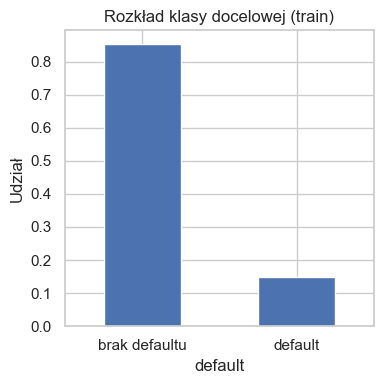

In [17]:
plt.figure(figsize=(4, 4))
df_train["default"].value_counts(normalize=True).plot(kind="bar")
plt.xticks([0, 1], ["brak defaultu", "default"], rotation=0)
plt.ylabel("Udział")
plt.title("Rozkład klasy docelowej (train)")
plt.tight_layout()
plt.show()

Histogramy wybranych cech - pokaznie jakości danych

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

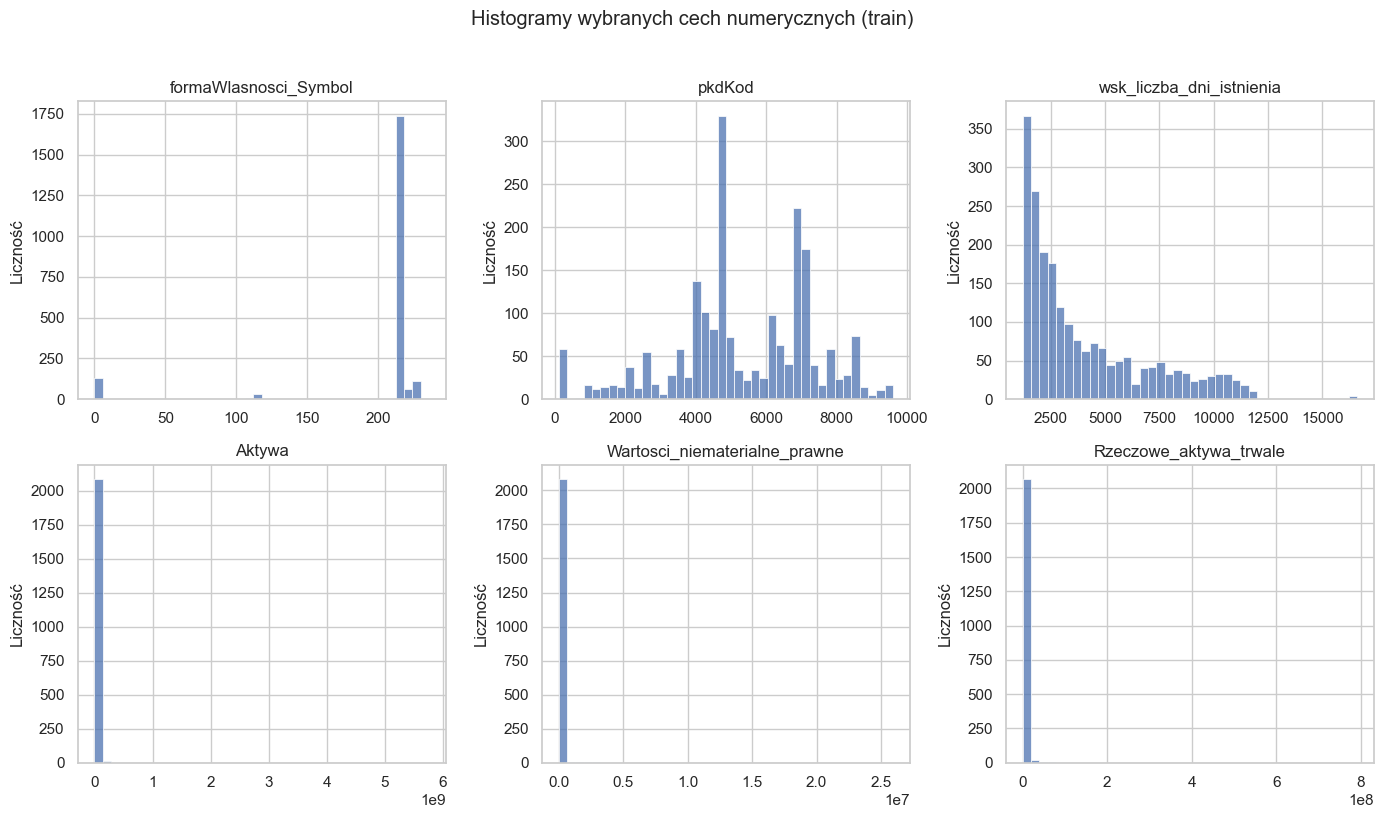

In [13]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.drop("default")
top_num = num_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for col, ax in zip(top_num, axes):
    sns.histplot(data=df_train, x=col, bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Liczność")

plt.suptitle("Histogramy wybranych cech numerycznych (train)", y=1.02)
plt.tight_layout()
plt.show()

Wykresy jądrowych estymatorów gęstości - lepsze histogramy

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 t

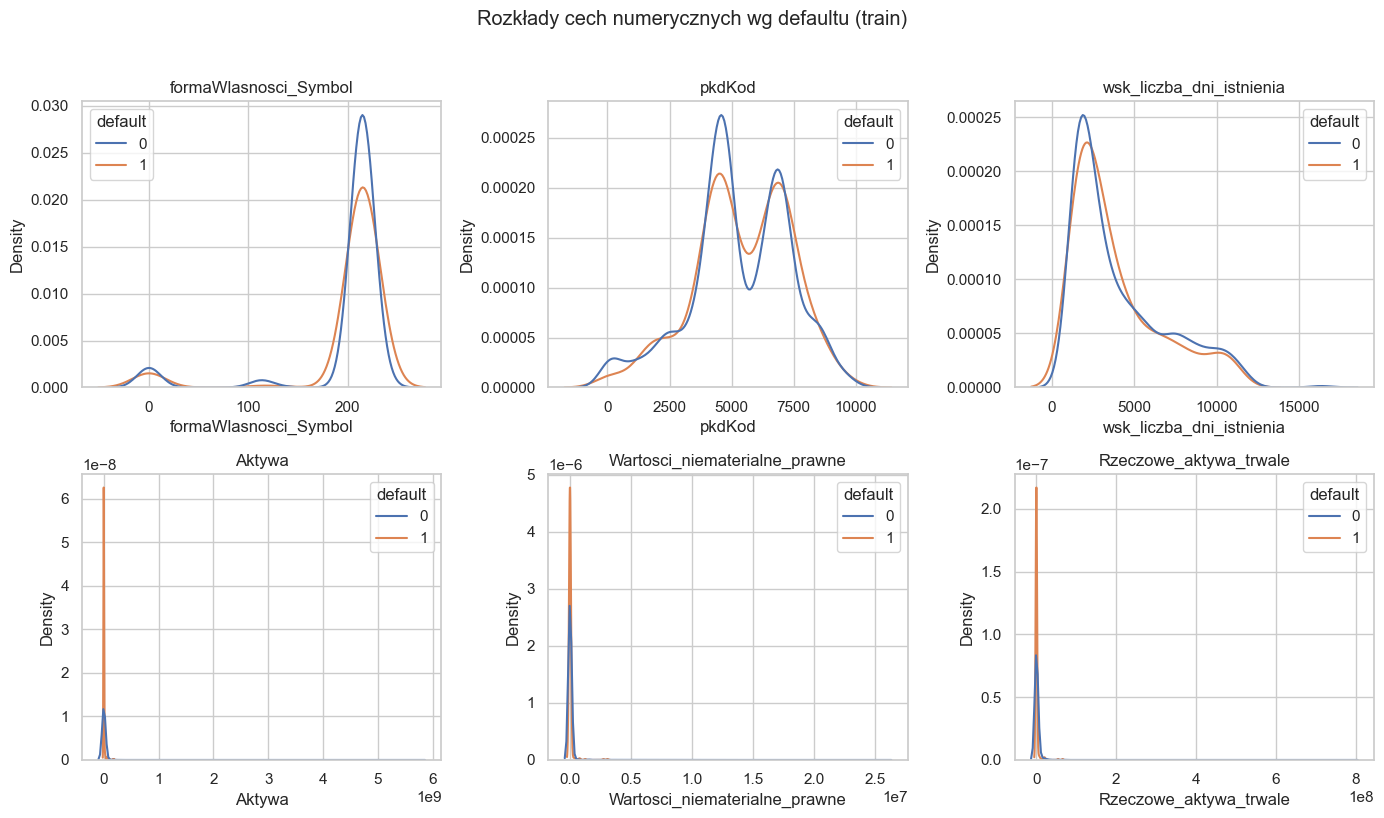

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for col, ax in zip(top_num, axes):
    sns.kdeplot(
        data=df_train,
        x=col,
        hue="default",
        common_norm=False,
        ax=ax
    )
    ax.set_title(col)

plt.suptitle("Rozkłady cech numerycznych wg defaultu (train)", y=1.02)
plt.tight_layout()
plt.show()

Korelacaje wybranych zmiennych


In [18]:
# Korelacja tylko między numerycznymi
corr_full = df_train[num_cols].corr().abs()

# Wybierzmy np. 15 cech
mean_corr = corr_full.mean().sort_values(ascending=False)
top_corr_cols = mean_corr.head(15).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_full.loc[top_corr_cols, top_corr_cols],
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    square=True
)
plt.title("Macierz korelacji (|r|) – top 15 cech numerycznych")
plt.tight_layout()
plt.show()


KeyboardInterrupt



Wykresy rozkład kwantylowy na deafault

In [19]:
def plot_target_rate_by_feature(df, feature, target="default", bins=10):
    """
    Dzieli cechę na kwantyle i rysuje default rate w każdym binie.
    """
    df_ = df[[feature, target]].dropna().copy()
    df_["bin"] = pd.qcut(df_[feature], q=bins, duplicates="drop")
    
    grouped = df_.groupby("bin")[target].agg(["mean", "size"]).reset_index()
    grouped.rename(columns={"mean": "default_rate", "size": "n"}, inplace=True)
    
    plt.figure(figsize=(8, 4))
    plt.plot(grouped["bin"].astype(str), grouped["default_rate"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Default rate")
    plt.xlabel(feature)
    plt.title(f"Default rate wg kwantyli cechy: {feature}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    display(grouped)

C:\Users\karol\AppData\Local\Temp\ipykernel_12612\1655656558.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_.groupby("bin")[target].agg(["mean", "size"]).reset_index()


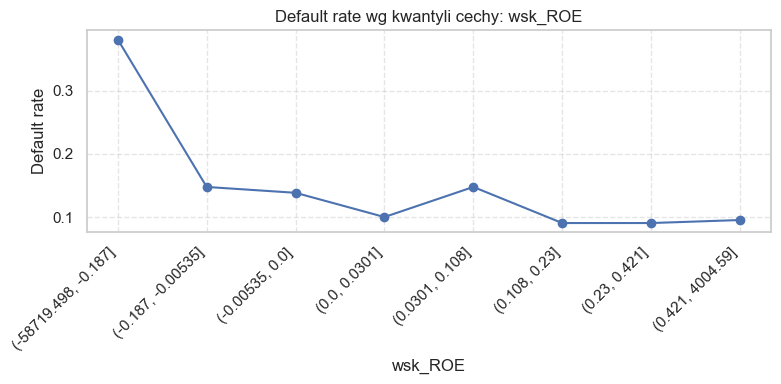

,bin,default_rate,n
0,"(-58719.498, -0.187]",0.380952,210
1,"(-0.187, -0.00535]",0.147619,210
2,"(-0.00535, 0.0]",0.138356,730
3,"(0.0, 0.0301]",0.100000,110
4,"(0.0301, 0.108]",0.147619,210
5,"(0.108, 0.23]",0.090476,210
6,"(0.23, 0.421]",0.090476,210
7,"(0.421, 4004.59]",0.095238,210


In [20]:
features_to_inspect = [
    "Kapital_wlasny",
    "wsk_ROE",
    "wsk_ogolnego_zadluzenia_pozyczki"
]

for feat in features_to_inspect:
    if feat in df_train.columns:
        plot_target_rate_by_feature(df_train, feat, target="default", bins=10)

## Tworzenie modeli

### Model 1 - regresja logistyczna

In [11]:
clf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(
        solver="saga",
        class_weight="balanced",
        max_iter=10000,
        n_jobs = -1,
        random_state=42
    ))
])

In [12]:
param_grid = [
    # Scenariusz 1: L1 (Lasso) i L2 (Ridge)
    {
        "model__penalty": ["l1", "l2"],
        # Sprawdzamy szeroki zakres C
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100] 
    },
    
    # Scenariusz 2: ElasticNet (Mieszanka)
    {
        "model__penalty": ["elasticnet"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.5, 0.9] 
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    clf, 
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [13]:
# Tranowanie modeli
grid.fit(X_trainval, y_trainval)

print(f"\nNajlepsze parametry: {grid.best_params_}")
print(f"Najlepsze AUC (CV): {grid.best_score_:.4f}")

best_logit_pipe = grid.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Najlepsze parametry: {'model__C': 0.01, 'model__penalty': 'l2'}
Najlepsze AUC (CV): 0.6795


In [14]:
y_proba_opt = best_logit_pipe.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_proba_opt)

print(f"Wynik CV (Train): {grid.best_score_:.4f}")
print(f"Wynik TEST (X_test): {auc_test:.4f}")

Wynik CV (Train): 0.6795
Wynik TEST (X_test): 0.6761


### Model Black box

In [25]:
xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1
    ))
])

In [26]:
param_dist = {
    "model__n_estimators": [200, 300, 400, 600],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__gamma": [0, 0.1, 0.3, 1.0],
    "model__reg_lambda": [0.1, 1.0, 5.0, 10.0],
    "model__reg_alpha": [0.0, 0.1, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [27]:
xgb_search.fit(X_trainval, y_trainval)
print("Najlepsze parametry:", xgb_search.best_params_)
print(f"Najlepsze AUC (CV): {xgb_search.best_score_:.4f}")

best_xgb_pipeline = xgb_search.best_estimator_
best_xgb_model = best_xgb_pipeline.named_steps["model"]

y_proba_test = best_xgb_pipeline.predict_proba(X_test)[:, 1]
print(f"AUC na teście: {roc_auc_score(y_test, y_proba_test):.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Najlepsze parametry: {'model__subsample': 0.6, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0.0, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Najlepsze AUC (CV): 0.7085
AUC na teście: 0.7287


## Metryki dla modeli

In [31]:
def calculate_ks(y_true, y_proba):
    # Liczenie KS

    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    return np.max(tpr - fpr)

In [32]:
def evaluate_models(models_dict, X_train, y_train, X_test, y_test):
    # Liczenie metryk

    results = []
    
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        
        y_train_flat = y_train.values.ravel() if hasattr(y_train, "values") else y_train
        y_test_flat = y_test.values.ravel() if hasattr(y_test, "values") else y_test
        
        y_prob_train = model.predict_proba(X_train)[:, 1]
        y_prob_test = model.predict_proba(X_test)[:, 1]
        
        auc_val = roc_auc_score(y_test_flat, y_prob_test)
        gini_val = 2 * auc_val - 1
        
        precision, recall, _ = precision_recall_curve(y_test_flat, y_prob_test)
        pr_auc_val = auc(recall, precision)
        
        ks_val = calculate_ks(y_test_flat, y_prob_test)
        logloss_val = log_loss(y_test_flat, y_prob_test)
        brier_val = brier_score_loss(y_test_flat, y_prob_test)
        
        auc_train = roc_auc_score(y_train_flat, y_prob_train)
        
        results.append({
            "Model": name,
            "AUC (Test)": auc_val,
            "AUC (Train)": auc_train,
            "Gini (Test)": gini_val,
            "KS Stat": ks_val,
            "PR-AUC": pr_auc_val,
            "Log-Loss": logloss_val,
            "Brier Score": brier_val,
            "Overfitting (Train-Test)": auc_train - auc_val
        })
        
        fpr, tpr, _ = roc_curve(y_test_flat, y_prob_test)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Losowy (Baseline)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Krzywe ROC - Porównanie Modeli')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return pd.DataFrame(results).set_index("Model")

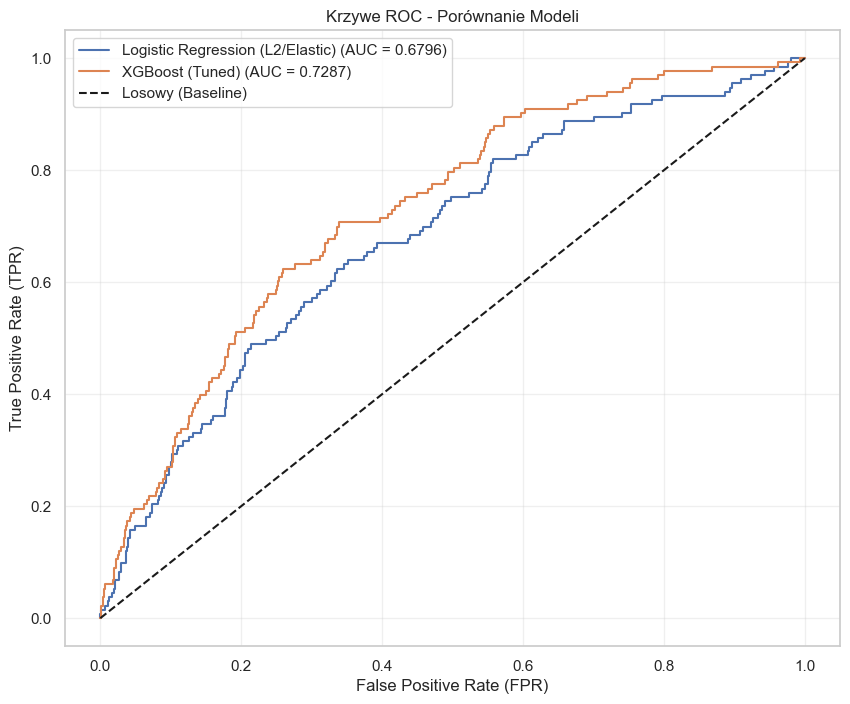


--- TABELA WYNIKÓW (RANKING) ---


,AUC (Test),AUC (Train),Gini (Test),KS Stat,PR-AUC,Log-Loss,Brier Score,Overfitting (Train-Test)
Model,,,,,,,,
Logistic Regression (L2/Elastic),0.679584,0.745567,0.359167,0.287685,0.265488,0.626073,0.215240,0.065983
XGBoost (Tuned),0.728735,0.897134,0.457470,0.367784,0.308570,0.379143,0.116059,0.168399


In [33]:
models_to_test = {
    "Logistic Regression (L2/Elastic)": grid.best_estimator_,
    "XGBoost (Tuned)": xgb_search.best_estimator_
}

df_results = evaluate_models(models_to_test, X_trainval, y_trainval, X_test, y_test)

# Tabela
print("\n--- TABELA WYNIKÓW (RANKING) ---")
display(df_results.style.background_gradient(cmap='Greens', subset=['AUC (Test)', 'KS Stat']))

## Interpretowlność modeli

### Regresja logistyczna

In [16]:
# Wyciągamy najlepszy pipeline z GridSearchCV
best_logit_pipe = grid.best_estimator_

prep = best_logit_pipe.named_steps["prep"]
logit = best_logit_pipe.named_steps["model"]

# Bierzemy nazwy cech po przejściu przez preprocessor
feature_names = prep.get_feature_names_out()

# Współczynniki log-odds i odds ratio
coefs = logit.coef_.ravel()
odds_ratios = np.exp(coefs)

coef_df = pd.DataFrame({
    "feature_full": feature_names,
    "coef": coefs,
    "odds_ratio": odds_ratios
})

# Rozpoznajemy wskaźniki braków i zwykłe cechy

# base_feature: zdejmujemy sufiks "_missing_indicator" jeśli jest
coef_df["base_feature"] = coef_df["feature_full"].str.replace(
    "_missing_indicator$", "", regex=True
)

#  Moduł współczynnika do rankingu
coef_df["abs_coef"] = coef_df["coef"].abs()

# TOP 20 zakodowanych cech
top_features_df = (
    coef_df.sort_values("abs_coef", ascending=False)
           .head(20)
)

print("TOP 20 cech (poziom zakodowany):")
display(
    top_features_df[["feature_full", "coef", "odds_ratio", "base_feature", "abs_coef"]]
        .style.format({"coef": "{:.4f}", "odds_ratio": "{:.3f}", "abs_coef": "{:.4f}"})
)

# Ranking na poziomie cechy bazowej
group_importance = (
    coef_df.groupby("base_feature")["abs_coef"]
           .max()
           .sort_values(ascending=False)
)

print("TOP 15 zmiennych bazowych (max |coef|):")
display(group_importance.head(15).to_frame(name="max_abs_coef")
        .style.format({"max_abs_coef": "{:.4f}"}))

TOP 20 cech (poziom zakodowany):


,feature_full,coef,odds_ratio,base_feature,abs_coef
49,wsk_ROE,-0.2759,0.759,wsk_ROE,0.2759
57,wsk_zadluzenie_kap_wlasnego,0.2186,1.244,wsk_zadluzenie_kap_wlasnego,0.2186
48,wsk_rent_operacyjna_aktywow,0.2019,1.224,wsk_rent_operacyjna_aktywow,0.2019
52,wsk_zysk_op_zobowiazania,-0.1873,0.829,wsk_zysk_op_zobowiazania,0.1873
28,Rozliczenia_miedzyokresowe_b,0.1469,1.158,Rozliczenia_miedzyokresowe_b,0.1469
47,wsk_ROA,-0.1464,0.864,wsk_ROA,0.1464
62,wsk_pokrycia_odsetek_zyskiem,-0.1384,0.871,wsk_pokrycia_odsetek_zyskiem,0.1384
42,wsk_marza_brutto_1,-0.1286,0.879,wsk_marza_brutto_1,0.1286
37,dotacje,-0.1205,0.886,dotacje,0.1205
81,schemat_wsk_rzis_SFJIN,0.1150,1.122,schemat_wsk_rzis_SFJIN,0.1150


TOP 15 zmiennych bazowych (max |coef|):


,max_abs_coef
base_feature,
wsk_ROE,0.2759
wsk_zadluzenie_kap_wlasnego,0.2186
wsk_rent_operacyjna_aktywow,0.2019
wsk_zysk_op_zobowiazania,0.1873
Rozliczenia_miedzyokresowe_b,0.1469
wsk_ROA,0.1464
wsk_pokrycia_odsetek_zyskiem,0.1384
wsk_marza_brutto_1,0.1286
dotacje,0.1205


In [18]:
#Dla każdej zmiennej bazowej wybieramy współczynnik o największym |coef| 
base_summary = (
    coef_df
    .loc[:, ["base_feature", "coef"]]      
    .groupby("base_feature", as_index=False)
    .apply(lambda g: g.loc[g["coef"].abs().idxmax()])  
    .reset_index(drop=True)
)

# Liczymy odds ratio i zmianę % w szansach (odds) 
base_summary["odds_ratio"] = np.exp(base_summary["coef"])
base_summary["odds_change_pct"] = (base_summary["odds_ratio"] - 1.0) * 100

#Kierunek wpływu (ułatwia opis)
def direction(row):
    if row["coef"] > 0:
        return "zwiększa ryzyko (PD ↑)"
    elif row["coef"] < 0:
        return "zmniejsza ryzyko (PD ↓)"
    else:
        return "brak wpływu"

base_summary["direction"] = base_summary.apply(direction, axis=1)

#Porządkujemy tabelę
base_interpretable = (
    base_summary
    .loc[:, ["base_feature", "coef", "odds_ratio", "odds_change_pct", "direction"]]
    .sort_values(by="coef", key=lambda s: s.abs(), ascending=False)
)


display(
    base_interpretable.head(15)
    .style.format({
        "coef": "{:.4f}",
        "odds_ratio": "{:.3f}",
        "odds_change_pct": "{:+.1f}%"
    })
)


C:\Users\karol\AppData\Local\Temp\ipykernel_28728\4193702878.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g["coef"].abs().idxmax()])


,base_feature,coef,odds_ratio,odds_change_pct,direction
49,wsk_ROE,-0.2759,0.759,-24.1%,zmniejsza ryzyko (PD ↓)
80,wsk_zadluzenie_kap_wlasnego,0.2186,1.244,+24.4%,zwiększa ryzyko (PD ↑)
68,wsk_rent_operacyjna_aktywow,0.2019,1.224,+22.4%,zwiększa ryzyko (PD ↑)
83,wsk_zysk_op_zobowiazania,-0.1873,0.829,-17.1%,zmniejsza ryzyko (PD ↓)
19,Rozliczenia_miedzyokresowe_b,0.1469,1.158,+15.8%,zwiększa ryzyko (PD ↑)
48,wsk_ROA,-0.1464,0.864,-13.6%,zmniejsza ryzyko (PD ↓)
63,wsk_pokrycia_odsetek_zyskiem,-0.1384,0.871,-12.9%,zmniejsza ryzyko (PD ↓)
55,wsk_marza_brutto_1,-0.1286,0.879,-12.1%,zmniejsza ryzyko (PD ↓)
31,dotacje,-0.1205,0.886,-11.4%,zmniejsza ryzyko (PD ↓)
45,schemat_wsk_rzis_SFJIN,0.1150,1.122,+12.2%,zwiększa ryzyko (PD ↑)


Interpretacja globalna

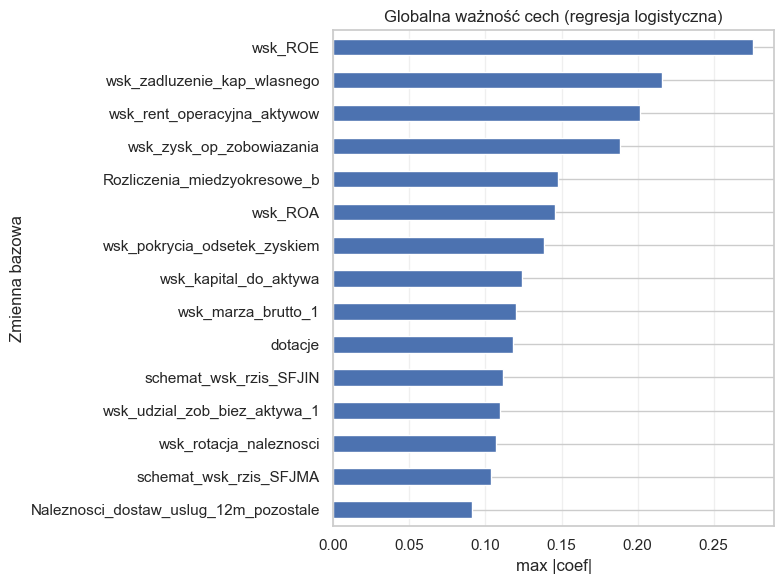

In [35]:
top_n = 15
top_base = group_importance.head(top_n)

plt.figure(figsize=(8, 6))
top_base.iloc[::-1].plot(kind="barh")
plt.xlabel("max |coef|")
plt.ylabel("Zmienna bazowa")
plt.title("Globalna ważność cech (regresja logistyczna)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

PDP

Kandydaci do PDP (numeryczne cechy bazowe): ['wsk_ROE', 'wsk_zadluzenie_kap_wlasnego', 'wsk_rent_operacyjna_aktywow', 'wsk_zysk_op_zobowiazania', 'Rozliczenia_miedzyokresowe_b', 'wsk_ROA', 'wsk_pokrycia_odsetek_zyskiem', 'wsk_kapital_do_aktywa', 'wsk_marza_brutto_1', 'dotacje']


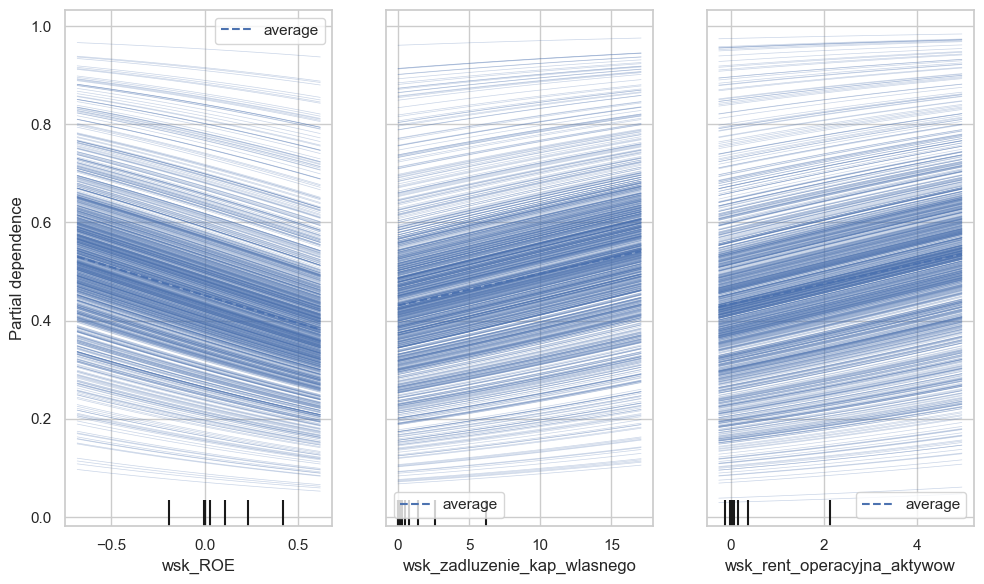

In [37]:
# numeryczne kolumny w oryginalnym X
numeric_cols = X_trainval.select_dtypes(include=[np.number]).columns

# bierzemy TOP 10 bazowych cech z rankingu i filtrujemy do tych, które są w X_trainval
candidate_features = list(group_importance.head(10).index)
features_for_pdp = [f for f in candidate_features if f in numeric_cols]

print("Kandydaci do PDP (numeryczne cechy bazowe):", features_for_pdp)

if len(features_for_pdp) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    PartialDependenceDisplay.from_estimator(
        best_logit_pipe,
        X_trainval,
        features=features_for_pdp[:3],  # 3 najważniejsze cechy numeryczne
        kind="both",                    # PDP + ICE
        subsample=1000,
        grid_resolution=20,
        ax=ax
    )

    plt.tight_layout()
    plt.show()
else:
    print("Brak numerycznych cech w TOP kandydatach do PDP.")

Lokalna interpretacja

In [38]:
def explain_logit_observation(pipe, X, idx):
    """
    Rozbija wynik regresji logistycznej na wkłady cech dla pojedynczej obserwacji.

    pipe : pipeline z krokami 'prep' i 'model'
    X    : DataFrame z oryginalnymi cechami (np. X_test)
    idx  : indeks obserwacji w X (label, nie pozycja)
    """
    # Rozbijamy pipeline
    prep = pipe.named_steps["prep"]
    model = pipe.named_steps["model"]
    
    # Wyciągamy jedną obserwację
    x_row = X.loc[[idx]]
    
    # Transformacja cech
    z = prep.transform(x_row)
    
    if isinstance(z, pd.DataFrame):
        feature_names = z.columns.to_numpy()
        z_arr = z.iloc[0].to_numpy()
    else:
        feature_names = prep.get_feature_names_out()
        if hasattr(z, "toarray"):
            z_arr = z.toarray().ravel()
        else:
            z_arr = np.asarray(z).ravel()
    
    coefs = model.coef_.ravel()
    intercept = model.intercept_[0]
    
    # Wkład każdej zakodowanej cechy
    contribs = z_arr * coefs
    logit_val = intercept + contribs.sum()
    prob = 1 / (1 + np.exp(-logit_val))
    
    contrib_df = pd.DataFrame({
        "feature_full": feature_names,
        "z_value": z_arr,
        "coef": coefs,
        "contribution": contribs
    })
    contrib_df["abs_contribution"] = contrib_df["contribution"].abs()
    
    # Nazwa bazowa cechy
    contrib_df["base_feature"] = contrib_df["feature_full"].str.replace(
        "_missing_indicator$", "", regex=True
    )
    
    # Sumujemy wkłady na poziomie zmiennej bazowej
    grouped = (
        contrib_df.groupby("base_feature")["contribution"]
                  .sum()
                  .reset_index()
    )
    grouped["abs_contribution"] = grouped["contribution"].abs()
    grouped = grouped.sort_values("abs_contribution", ascending=False)
    
    return {
        "idx": idx,
        "intercept": intercept,
        "logit": logit_val,
        "prob": prob,
        "grouped_contribs": grouped,
        "full_contribs": contrib_df.sort_values("abs_contribution", ascending=False),
        "x_original": x_row
    }

In [39]:
idx_default = y_test[y_test == 1].index[0]
idx_good    = y_test[y_test == 0].index[0]

case_default = explain_logit_observation(best_logit_pipe, X_test, idx_default)
case_good    = explain_logit_observation(best_logit_pipe, X_test, idx_good)

print("=== CASE: KLIENT Z DEFAULTEM ===")
print(f"Index: {case_default['idx']}")
print(f"PD(model): {case_default['prob']:.4f}")
print("\nTop 10 wkładów (bazowe zmienne):")
display(case_default["grouped_contribs"].head(10))
print("\nOryginalne cechy:")
display(case_default["x_original"])

print("\n=== CASE: KLIENT BEZ DEFAULTU ===")
print(f"Index: {case_good['idx']}")
print(f"PD(model): {case_good['prob']:.4f}")
print("\nTop 10 wkładów (bazowe zmienne):")
display(case_good["grouped_contribs"].head(10))
print("\nOryginalne cechy:")
display(case_good["x_original"])

=== CASE: KLIENT Z DEFAULTEM ===
Index: 370
PD(model): 0.6056

Top 10 wkładów (bazowe zmienne):


,base_feature,contribution,abs_contribution
69,wsk_rent_operacyjna_aktywow,1.188112,1.188112
85,wsk_zysk_op_zobowiazania,-0.372063,0.372063
54,wsk_kapital_do_aktywa,-0.349783,0.349783
33,formaWlasnosci_Symbol,0.240061,0.240061
39,missingindicator_wsk_plynnosc_biez_1,0.172111,0.172111
41,pkdKod,0.140249,0.140249
76,wsk_struktury_finansowania,-0.075874,0.075874
60,wsk_obrotowosc_gotowkowa,-0.074052,0.074052
52,wsk_ebitda_zobowiazan_odsetki_3,-0.051383,0.051383
55,wsk_liczba_dni_istnienia,0.043362,0.043362



Oryginalne cechy:


,formaWlasnosci_Symbol,pkdKod,wsk_liczba_dni_istnienia,Aktywa,Wartosci_niematerialne_prawne,Rzeczowe_aktywa_trwale,Naleznosci_dlugoterminowe,Aktywa_obrotowe,Zapasy,Naleznosci_dostaw_uslug_pow12m_powiazane,...,wsk_obrotowsci_naleznosci,wsk_plynnosc_biez_1,wsk_udzial_zob_biez_aktywa_1,wsk_udzial_zob_biez_aktywa_2,wsk_zysk_ebitda_1,wsk_obrotowosc_gotowkowa,wsk_struktura_majatku,wsk_zast_kapitalu_obcego,wsk_sytuacji_fin,wsk_struktura_kap_wlasnego_s_2
370,214,6311,6177,97911.67,0.0,0.0,0.0,86627.98,0.0,0.0,...,8.362707,NaN,0.0,0.0,0.0,7244.4445,0.130255,0.082608,97.364064,0.926912



=== CASE: KLIENT BEZ DEFAULTU ===
Index: 686
PD(model): 0.1590

Top 10 wkładów (bazowe zmienne):


,base_feature,contribution,abs_contribution
64,wsk_pokrycia_odsetek_zyskiem,-0.651119,0.651119
50,wsk_ROE,-0.501969,0.501969
49,wsk_ROA,-0.388197,0.388197
54,wsk_kapital_do_aktywa,-0.202759,0.202759
78,wsk_udzial_zob_biez_aktywa_1,0.177342,0.177342
66,wsk_pokrycie_wyd_fin_gotowkowe_1,0.161545,0.161545
41,pkdKod,0.160427,0.160427
62,wsk_ogolnego_zadluzenia_1,0.123083,0.123083
46,schemat_wsk_rzis_SFJIN,0.111756,0.111756
67,wsk_rent_kapitalu,0.110475,0.110475



Oryginalne cechy:


,formaWlasnosci_Symbol,pkdKod,wsk_liczba_dni_istnienia,Aktywa,Wartosci_niematerialne_prawne,Rzeczowe_aktywa_trwale,Naleznosci_dlugoterminowe,Aktywa_obrotowe,Zapasy,Naleznosci_dostaw_uslug_pow12m_powiazane,...,wsk_obrotowsci_naleznosci,wsk_plynnosc_biez_1,wsk_udzial_zob_biez_aktywa_1,wsk_udzial_zob_biez_aktywa_2,wsk_zysk_ebitda_1,wsk_obrotowosc_gotowkowa,wsk_struktura_majatku,wsk_zast_kapitalu_obcego,wsk_sytuacji_fin,wsk_struktura_kap_wlasnego_s_2
686,0,7219,1966,2726713.19,0.0,311359.89,0.0,2415353.3,0.0,0.0,...,4.174314,1.914455,0.462696,-0.081397,0.872648,2.60018,0.128909,0.522342,9.008275,1.178538


### XGBoost

In [40]:
# Najlepszy pipeline z RandomizedSearchCV
best_xgb_pipe = xgb_search.best_estimator_
pipe_xgb = best_xgb_pipe

# Dane treningowe do SHAP
X_train_for_shap = X_trainval.copy()
y_train_for_shap = y_trainval.copy()

print("Rozmiar X_train_for_shap:", X_train_for_shap.shape)

# Inicjalizacja SHAP
shap.initjs()

background = X_train_for_shap.sample(
    n=min(50, len(X_train_for_shap)),
    random_state=42
)

Rozmiar X_train_for_shap: (2100, 79)


In [41]:
# Funkcja predykcyjna zwracająca P(default=1) dla pipeline
def xgb_pipe_predict(X):
    if isinstance(X, pd.DataFrame):
        X_df = X[X_train_for_shap.columns]
    else:
        X_df = pd.DataFrame(X, columns=X_train_for_shap.columns)
    return pipe_xgb.predict_proba(X_df)[:, 1]

In [42]:
# Tworzymy model-agnostic explainer
explainer_shap = shap.KernelExplainer(xgb_pipe_predict, background)

# Dane do globalnych wykresów
X_shap = X_train_for_shap.sample(
    n=min(300, len(X_train_for_shap)),
    random_state=123
)

In [43]:
# SHAP values dla tej próbki (dla klasy 1)
shap_values_train = explainer_shap.shap_values(X_shap, nsamples="auto")

print("Kształt X_shap:", X_shap.shape)
print("Kształt shap_values_train:", np.array(shap_values_train).shape)

# Nazwy cech
feature_names_orig = X_shap.columns.tolist()

  0%|          | 0/300 [00:00<?, ?it/s]

Kształt X_shap: (300, 79)
Kształt shap_values_train: (300, 79)


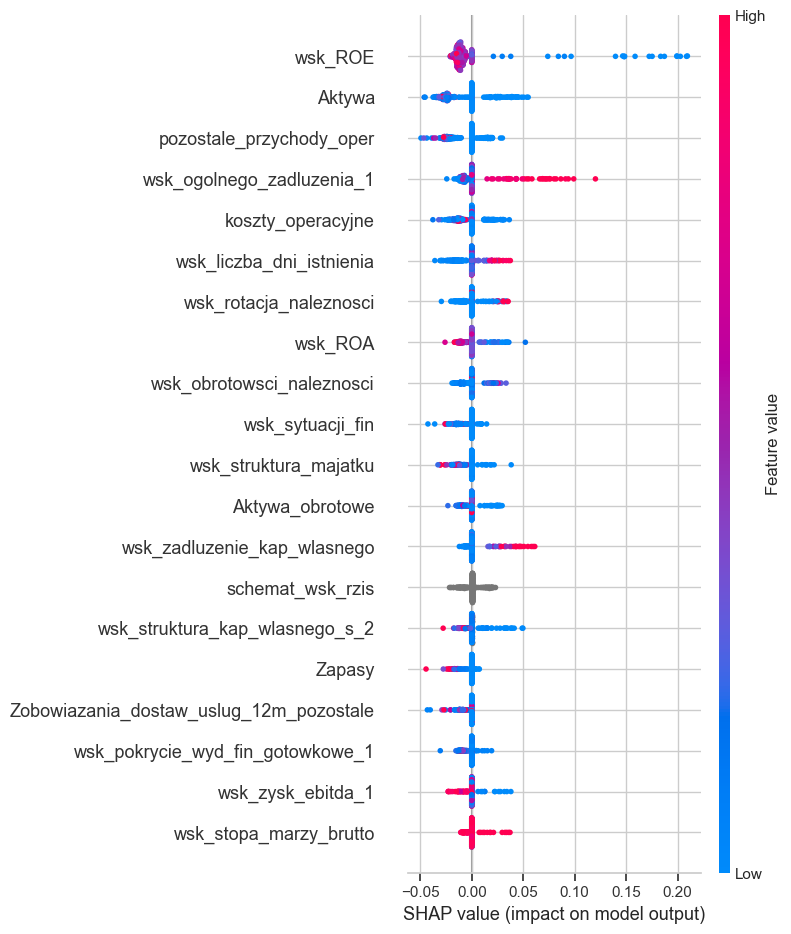

In [44]:
# Beeswarm –> globalne znaczenie cech
shap.summary_plot(
    shap_values_train,
    X_shap,
    feature_names=feature_names_orig,
    show=True
)

In [8]:
#Shap na tescie
X_test_shap = X_test_final[X_train_for_shap.columns]

X_test_sample = X_test_shap.sample(
    n=min(300, len(X_test_shap)),
    random_state=123
)

shap_values_test = explainer_shap.shap_values(
    X_test_sample,
    nsamples="auto"
)

print("Kształt X_test_sample:", X_test_sample.shape)
print("Kształt shap_values_test:", np.array(shap_values_test).shape)

# Rysujemy beeswarm dla TESTU
shap.summary_plot(
    shap_values_test,
    X_test_sample,
    feature_names=feature_names_orig,
    show=True
)


NameError: name 'X_test_final' is not defined

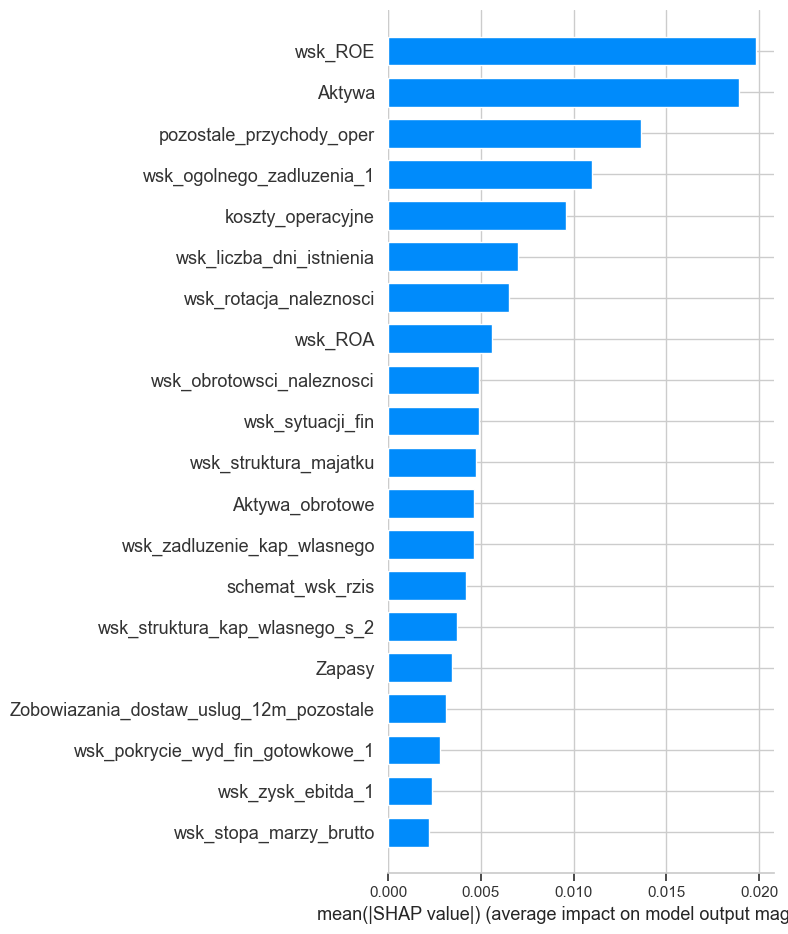

In [47]:
# Barplot średniego |SHAP| –> ranking cech
shap.summary_plot(
    shap_values_train,
    X_shap,
    feature_names=feature_names_orig,
    plot_type="bar",
    show=True)

Dependence plot

Dependence plot dla cechy: wsk_ROE


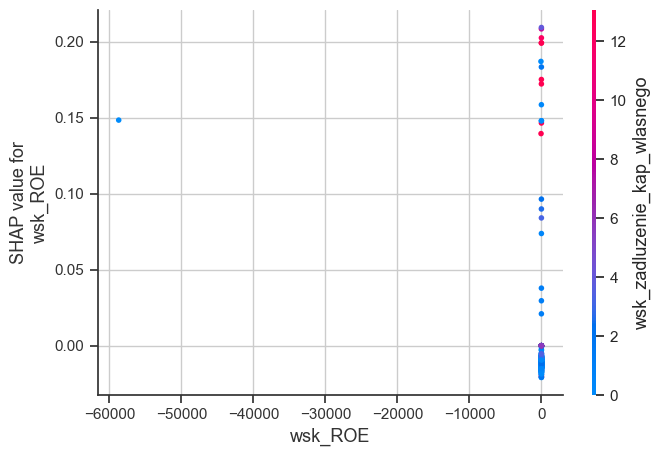

Dependence plot dla cechy: Aktywa


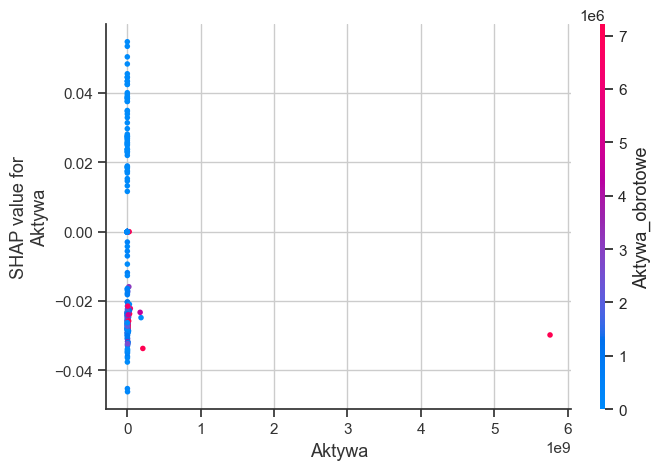

In [50]:
top_shap_features = [
    "wsk_ROE",
    "Aktywa"
]

for fname in top_shap_features:
    print(f"Dependence plot dla cechy: {fname}")
    shap.dependence_plot(
        fname,
        shap_values_train,
        X_shap,
        feature_names=feature_names_orig,
        show=True
    )

Lokalna interpretowalność

In [51]:
# Wybierzmy klienta z defaultem i bez defaultu
idx_default = y_test[y_test == 1].index[0]
idx_good    = y_test[y_test == 0].index[0]

# Funkcja dla pojedynczej obserwacji
def shap_for_single_idx_kernel(idx):
    x_row = X_test.loc[[idx]]
    shap_row = explainer_shap.shap_values(x_row, nsamples="auto")[0]
    
    return {
        "idx": idx,
        "x_original": x_row,
        "shap_row": shap_row,
        "expected_value": explainer_shap.expected_value,
        "feature_names": feature_names_orig
    }

In [52]:
case_xgb_default = shap_for_single_idx_kernel(idx_default)
case_xgb_good    = shap_for_single_idx_kernel(idx_good)

print("PD XGB dla klienta z defaultem:",
      pipe_xgb.predict_proba(X_test.loc[[idx_default]])[0, 1])
print("PD XGB dla klienta bez defaultu:",
      pipe_xgb.predict_proba(X_test.loc[[idx_good]])[0, 1])


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

PD XGB dla klienta z defaultem: 0.102206506
PD XGB dla klienta bez defaultu: 0.033944372


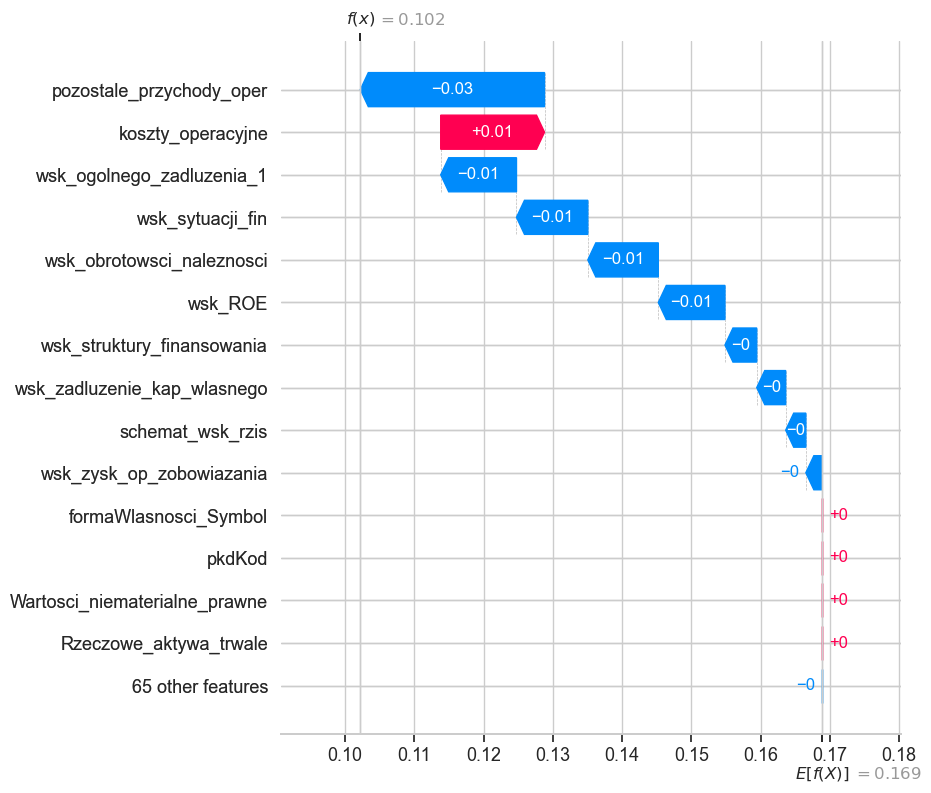

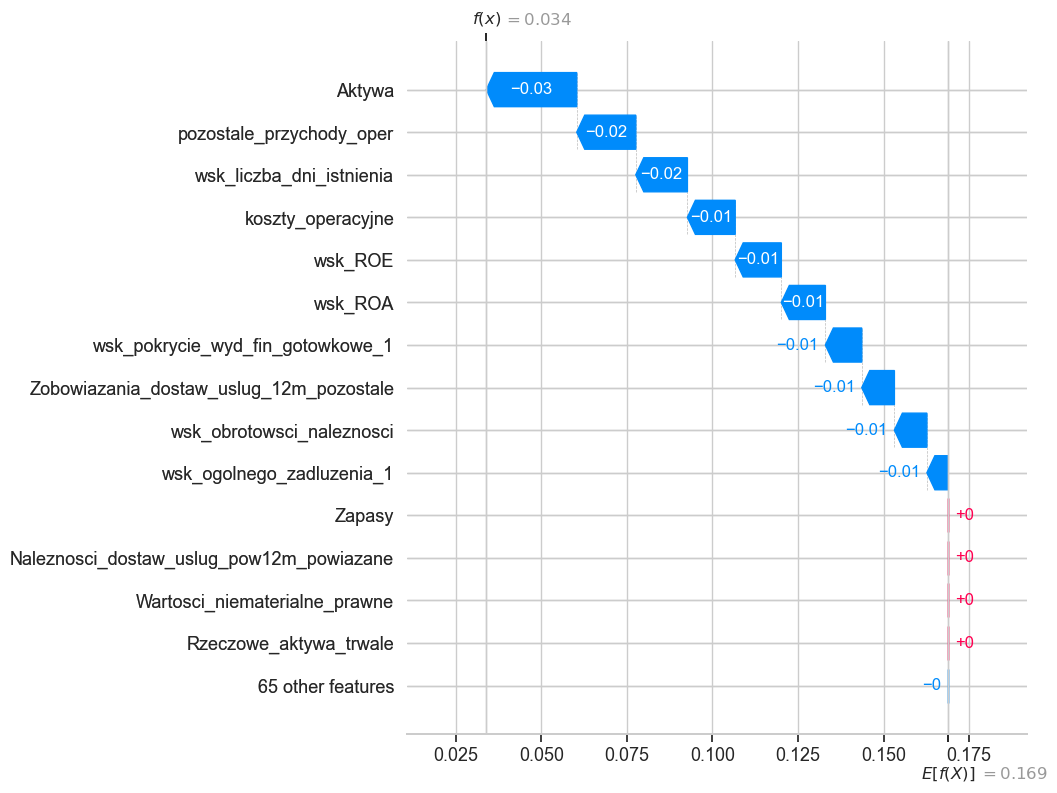

In [53]:
# Waterfall –> rozkład PD na wkłady cech

# Klient z defaultem
shap.plots._waterfall.waterfall_legacy(
    case_xgb_default["expected_value"],
    case_xgb_default["shap_row"],
    feature_names=case_xgb_default["feature_names"],
    max_display=15
)

# Klient bez defaultu
shap.plots._waterfall.waterfall_legacy(
    case_xgb_good["expected_value"],
    case_xgb_good["shap_row"],
    feature_names=case_xgb_good["feature_names"],
    max_display=15
)

## Kalibracja


### Zbiór walidacyjny

In [54]:
final_xgb_pipe = best_xgb_pipe

# 2. Dzielimy X_test na:
# - X_calib -> do kalibracji
# - X_test_final -> ostateczny testowy
X_calib, X_test_final, y_calib, y_test_final = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    stratify=y_test,
    random_state=42
)

print(f"Zbiór do kalibracji: {X_calib.shape}")
print(f"Ostateczny zbiór testowy: {X_test_final.shape}")

Zbiór do kalibracji: (450, 79)
Ostateczny zbiór testowy: (450, 79)


### Kalibracja dla xgboost

In [55]:
cal_isotonic = CalibratedClassifierCV(final_xgb_pipe, method='isotonic', cv='prefit')
cal_isotonic.fit(X_calib, y_calib)

cal_sigmoid = CalibratedClassifierCV(final_xgb_pipe, method='sigmoid', cv='prefit')
cal_sigmoid.fit(X_calib, y_calib)

print("Modele skalibrowane")

Modele skalibrowane


C:\Users\karol\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\karol\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



--- WYNIKI KALIBRACJI (X_test_final) ---
XGBoost Surowy:   Brier=0.1158, AUC=0.7360
XGBoost Isotonic: Brier=0.1153, AUC=0.7397
XGBoost Sigmoid:  Brier=0.1172, AUC=0.7360


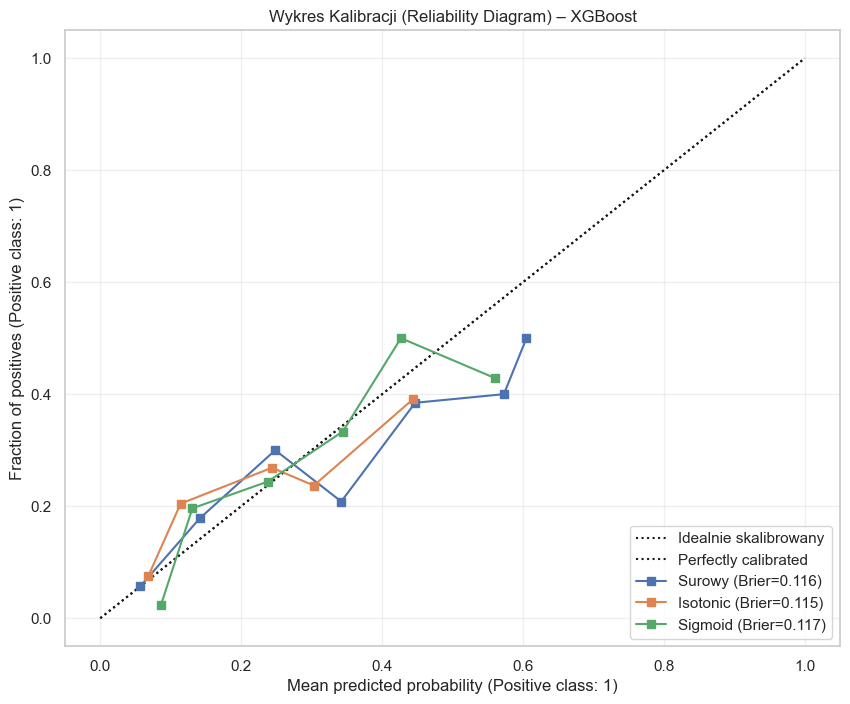

In [56]:
# prawdopodobieństwa
prob_raw = final_xgb_pipe.predict_proba(X_test_final)[:, 1]
# Po kalibracji
prob_iso = cal_isotonic.predict_proba(X_test_final)[:, 1]
prob_sig = cal_sigmoid.predict_proba(X_test_final)[:, 1]

# Brier Score
brier_raw = brier_score_loss(y_test_final, prob_raw)
brier_iso = brier_score_loss(y_test_final, prob_iso)
brier_sig = brier_score_loss(y_test_final, prob_sig)

# AUC
auc_raw = roc_auc_score(y_test_final, prob_raw)
auc_iso = roc_auc_score(y_test_final, prob_iso)
auc_sig = roc_auc_score(y_test_final, prob_sig)

print(f"\n--- WYNIKI KALIBRACJI (X_test_final) ---")
print(f"XGBoost Surowy:   Brier={brier_raw:.4f}, AUC={auc_raw:.4f}")
print(f"XGBoost Isotonic: Brier={brier_iso:.4f}, AUC={auc_iso:.4f}")
print(f"XGBoost Sigmoid:  Brier={brier_sig:.4f}, AUC={auc_sig:.4f}")

# Reliability / Calibration plot
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label="Idealnie skalibrowany")

CalibrationDisplay.from_predictions(
    y_test_final, prob_raw, n_bins=10,
    name=f"Surowy (Brier={brier_raw:.3f})",
    ax=plt.gca()
)
CalibrationDisplay.from_predictions(
    y_test_final, prob_iso, n_bins=10,
    name=f"Isotonic (Brier={brier_iso:.3f})",
    ax=plt.gca()
)
CalibrationDisplay.from_predictions(
    y_test_final, prob_sig, n_bins=10,
    name=f"Sigmoid (Brier={brier_sig:.3f})",
    ax=plt.gca()
)

plt.title("Wykres Kalibracji (Reliability Diagram) – XGBoost")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [57]:
def logit(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

# ---- 2A. Dopasowujemy model: y_calib ~ a + b * logit(prob_raw na X_calib) ----
prob_raw_calib = final_xgb_pipe.predict_proba(X_calib)[:, 1]
logit_raw_calib = logit(prob_raw_calib).reshape(-1, 1)

# Model bez regularizacji (C duże)
calib_lr = LogisticRegression(
    penalty="l2",
    solver="saga",
    max_iter=1000,
    C = 0.1
)
calib_lr.fit(logit_raw_calib, y_calib)

a = calib_lr.intercept_[0]
b = calib_lr.coef_.ravel()[0]
print(f"Calibration-in-the-large: intercept={a:.4f}, slope={b:.4f}")

# ---- 2B. Stosujemy tę transformację na X_test_final ----
logit_raw_test = logit(prob_raw)
logit_calibrated = a + b * logit_raw_test
prob_cit = 1 / (1 + np.exp(-logit_calibrated))   # CIT = calibration-in-the-large + slope

brier_cit = brier_score_loss(y_test_final, prob_cit)
auc_cit = roc_auc_score(y_test_final, prob_cit)

print(f"XGBoost CIT (intercept+slope): Brier={brier_cit:.4f}, AUC={auc_cit:.4f}")

Calibration-in-the-large: intercept=-0.5051, slope=0.6745
XGBoost CIT (intercept+slope): Brier=0.1154, AUC=0.7360


In [58]:
def shift_probs_to_target_mean(probs, target_pd=0.04, tol=1e-6, max_iter=50):
    """
    Szukamy stałej δ, tak aby mean(sigmoid(logit(p) + δ)) ≈ target_pd.
    """
    logits = logit(probs)

    # prosty bisekcja w przedziale [-10, 10]
    low, high = -10.0, 10.0
    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        p_new = 1 / (1 + np.exp(-(logits + mid)))
        m = p_new.mean()
        if abs(m - target_pd) < tol:
            return p_new, mid
        if m > target_pd:
            high = mid
        else:
            low = mid
    # jeśli nie zbiegnie idealnie, zwracamy ostatnią wersję
    p_new = 1 / (1 + np.exp(-(logits + mid)))
    return p_new, mid

In [59]:
# --- 3. Kalibracja do 4% na bazie isotonic (na X_test_final) ---

target_pd = 0.04

# baza do 4%: tu używamy prob_iso (XGBoost + isotonic na X_test_final)
prob_4, delta_4 = shift_probs_to_target_mean(prob_iso, target_pd=target_pd)

print(f"Średnia PD przed 4% (isotonic): {prob_iso.mean():.4f}")
print(f"Średnia PD po 4%:               {prob_4.mean():.4f}")
print(f"Zastosowany shift δ: {delta_4:.4f}")

Średnia PD przed 4% (isotonic): 0.1379
Średnia PD po 4%:               0.0400
Zastosowany shift δ: -1.4449


In [60]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Prosty ECE: średnie bezwzględne odchylenie między
    średnią przewidywaną PD a częstością defaultów w koszykach.
    """
    # 'quantile' -> w każdym koszyku ~tyle samo obserwacji
    prob_true, prob_pred = calibration_curve(
        y_true, y_prob,
        n_bins=n_bins,
        strategy='quantile'
    )
    ece = np.mean(np.abs(prob_true - prob_pred))
    return ece

ece_raw = expected_calibration_error(y_test_final, prob_raw)
ece_iso = expected_calibration_error(y_test_final, prob_iso)
ece_sig = expected_calibration_error(y_test_final, prob_sig)

print(f"\n--- Średni Błąd Kalibracji (ECE) ---")
print(f"XGBoost Surowy:   {ece_raw:.1%} (Średnio myli się o {ece_raw*100:.1f} p.p.)")
print(f"XGBoost Isotonic: {ece_iso:.1%} (Średnio myli się o {ece_iso*100:.1f} p.p.)")
print(f"XGBoost Sigmoid:  {ece_sig:.1%} (Średnio myli się o {ece_sig*100:.1f} p.p.)")


--- Średni Błąd Kalibracji (ECE) ---
XGBoost Surowy:   4.8% (Średnio myli się o 4.8 p.p.)
XGBoost Isotonic: 4.3% (Średnio myli się o 4.3 p.p.)
XGBoost Sigmoid:  6.3% (Średnio myli się o 6.3 p.p.)


In [61]:
brier_4 = brier_score_loss(y_test_final, prob_4)
auc_4 = roc_auc_score(y_test_final, prob_4)
ece_4 = expected_calibration_error(y_test_final, prob_4)

print(f"\nXGBoost po kalibracji do 4% (na bazie isotonic):")
print(f"Brier={brier_4:.4f}, AUC={auc_4:.4f}, ECE={ece_4:.1%}")


XGBoost po kalibracji do 4% (na bazie isotonic):
Brier=0.1304, AUC=0.7397, ECE=11.8%


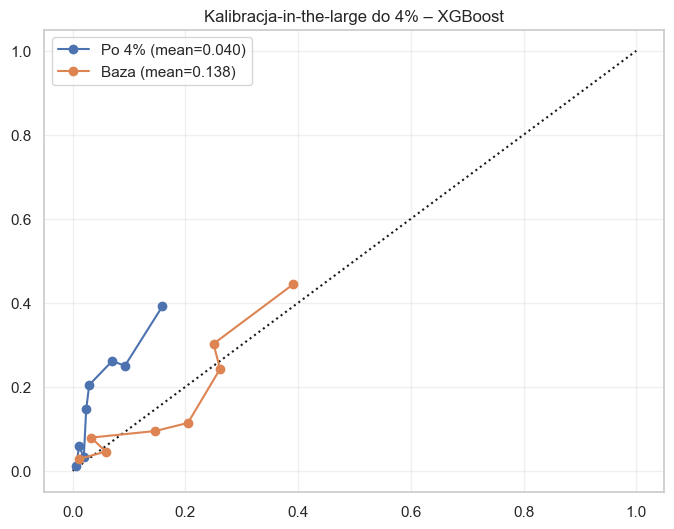

In [69]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(
    y_test_final, prob_4, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(8, 6))
plt.plot([0,1],[0,1],"k:")

plt.plot(mean_pred, frac_pos, "o-", label=f"Po 4% (mean={prob_4.mean():.3f})")
plt.plot(*calibration_curve(y_test_final, prob_base, n_bins=10, strategy="quantile"), 
         "o-", label=f"Baza (mean={prob_base.mean():.3f})")

plt.legend()
plt.grid(alpha=0.3)
plt.title("Kalibracja-in-the-large do 4% – XGBoost")
plt.show()


### Kalibracja dla Regresji logistycznej

In [63]:
def calibration_slope_intercept(y_true, y_proba):
    """
    Dopasowanie modelu: y ~ a + b * logit(p)
    Zwraca slope (b) i intercept (a).
    """
    eps = 1e-15
    logit_p = np.log((y_proba + eps) / (1 - y_proba + eps)).reshape(-1, 1)
    lr = LogisticRegression(
        solver="saga",
        penalty="l2",
        max_iter=1000,
        C = 0.1
    )
    lr.fit(logit_p, y_true)
    return lr.coef_[0, 0], lr.intercept_[0]

In [64]:
def apply_slope_intercept(p, slope, intercept):
    eps = 1e-15
    logit_p = np.log((p + eps) / (1 - p + eps))
    logit_new = intercept + slope * logit_p
    return 1 / (1 + np.exp(-logit_new))

In [65]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy="quantile"
    )
    return np.mean(np.abs(prob_true - prob_pred))

In [66]:
def plot_calibration_curves(y_true, prob_dict, n_bins=10, title="Krzywe kalibracji (reliability)"):
    plt.figure(figsize=(7, 7))
    plt.plot([0, 1], [0, 1], "k--", label="Idealna kalibracja")
    
    for name, p in prob_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins)
        plt.plot(mean_pred, frac_pos, marker="o", linewidth=1, label=name)
    
    plt.xlabel("Średnie przewidziane PD w binie")
    plt.ylabel("Rzeczywista częstość defaultu w binie")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

In [67]:
final_logit_pipe = best_logit_pipe

# Baza na finalnym teście 
p_test_base_logit = final_logit_pipe.predict_proba(X_test_final)[:, 1]

# Platt scaling (sigmoid) + CIL
base_for_platt = clone(final_logit_pipe)
base_for_platt.fit(X_trainval, y_trainval)

cal_platt_logit = CalibratedClassifierCV(
    estimator=base_for_platt,
    method="sigmoid",
    cv="prefit"
)
cal_platt_logit.fit(X_calib, y_calib)

# predykcje po Platt na zbiorze kalibracyjnym
p_calib_platt = cal_platt_logit.predict_proba(X_calib)[:, 1]

# slope + intercept (CIL) na zbiorze kalibracyjnym
slope_platt, intercept_platt = calibration_slope_intercept(y_calib, p_calib_platt)

# Platt na finalnym teście
p_test_platt = cal_platt_logit.predict_proba(X_test_final)[:, 1]

# Platt + CIL
p_test_platt_cil = apply_slope_intercept(p_test_platt, slope_platt, intercept_platt)

# Isotonic

base_for_iso = clone(final_logit_pipe)
base_for_iso.fit(X_trainval, y_trainval)

cal_iso_logit = CalibratedClassifierCV(
    estimator=base_for_iso,
    method="isotonic",
    cv="prefit"
)
cal_iso_logit.fit(X_calib, y_calib)

p_test_iso_logit = cal_iso_logit.predict_proba(X_test_final)[:, 1]

C:\Users\karol\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\karol\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


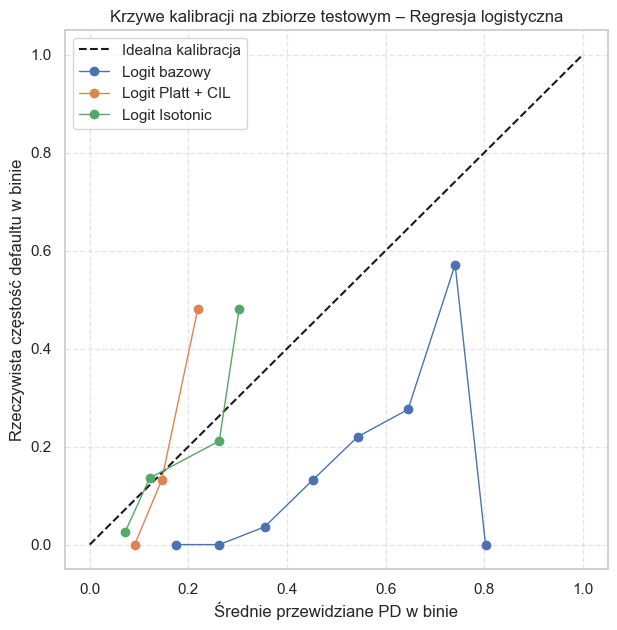

Logit bazowy        Brier=0.2133  AUC=0.7326  ECE=31.5%
Logit Platt + CIL   Brier=0.1202  AUC=0.7326  ECE=6.9%
Logit Isotonic      Brier=0.1161  AUC=0.7348  ECE=7.6%


In [57]:
y_true_final = np.asarray(y_test_final)

prob_dict_logit = {
    "Logit bazowy": p_test_base_logit,
    "Logit Platt + CIL": p_test_platt_cil,
    "Logit Isotonic": p_test_iso_logit
}

plot_calibration_curves(
    y_true=y_true_final,
    prob_dict=prob_dict_logit,
    n_bins=10,
    title="Krzywe kalibracji na zbiorze testowym – Regresja logistyczna"
)

# Metryki
for name, p in prob_dict_logit.items():
    brier = brier_score_loss(y_true_final, p)
    auc = roc_auc_score(y_true_final, p)
    ece = expected_calibration_error(y_true_final, p)
    print(f"{name:18s}  Brier={brier:.4f}  AUC={auc:.4f}  ECE={ece:.1%}")

In [58]:
def shift_probs_to_target_mean(probs, target_pd=0.04, tol=1e-6, max_iter=50):
    def logit(p, eps=1e-12):
        p = np.clip(p, eps, 1 - eps)
        return np.log(p / (1 - p))
    
    logits = logit(probs)
    low, high = -10.0, 10.0
    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        p_new = 1 / (1 + np.exp(-(logits + mid)))
        m = p_new.mean()
        if abs(m - target_pd) < tol:
            return p_new, mid
        if m > target_pd:
            high = mid
        else:
            low = mid
    p_new = 1 / (1 + np.exp(-(logits + mid)))
    return p_new, mid

target_pd = 0.04
prob_base_logit = p_test_iso_logit  # np. isotonic jako baza
p_test_4, delta_4 = shift_probs_to_target_mean(prob_base, target_pd=0.04)

print(f"Średnia PD przed 4%: {prob_base.mean():.4f}")
print(f"Średnia PD po 4%:   {p_test_4.mean():.4f}")
print(f"Zastosowany shift δ: {delta_4:.4f}")

Średnia PD przed 4%: 0.1420
Średnia PD po 4%:   0.0400
Zastosowany shift δ: -1.4828


## Próg decyzyjny z funkcji kosztu

In [59]:
def cost_for_threshold(y_true, y_prob, thr, cost_fp=1, cost_fn=5, cost_tp=0, cost_tn=0):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = (
        cost_fp * fp +
        cost_fn * fn +
        cost_tp * tp +
        cost_tn * tn
    )
    return cost, (tn, fp, fn, tp)

In [60]:
def find_best_threshold(y_true, y_prob, cost_fp=1, cost_fn=5, n_points=200):
    thresholds = np.linspace(0.0, 1.0, n_points)
    costs = []
    for t in thresholds:
        c, _ = cost_for_threshold(y_true, y_prob, t, cost_fp, cost_fn)
        costs.append(c)
    costs = np.array(costs)
    best_idx = costs.argmin()
    return thresholds[best_idx], thresholds, costs

In [61]:
prob_base_final = cal_isotonic.predict_proba(X_test_final)[:, 1]
print("len(prob_base_final) =", len(prob_base_final))

len(prob_base_final) = 450


In [62]:
target_pd = 0.04

p_test_4, delta_4 = shift_probs_to_target_mean(prob_base_final, target_pd=target_pd)

print("len(y_test_final) =", len(y_test_final))
print("len(p_test_4)     =", len(p_test_4))
print("mean(p_test_4)    =", p_test_4.mean())

len(y_test_final) = 450
len(p_test_4)     = 450
mean(p_test_4)    = 0.04000036722899618


In [63]:
best_thr, thr_grid, cost_grid = find_best_threshold(
    y_test_final.values,
    p_test_4,
    cost_fp=1,
    cost_fn=5
)

Optymalny próg wg funkcji kosztu: 0.0352


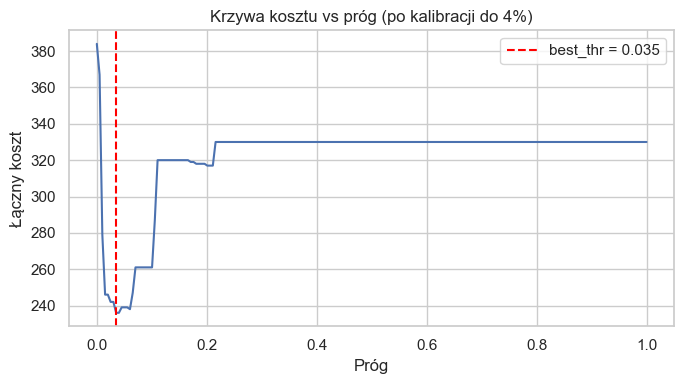

In [64]:
print(f"Optymalny próg wg funkcji kosztu: {best_thr:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(thr_grid, cost_grid)
plt.axvline(best_thr, linestyle="--", color="red", label=f"best_thr = {best_thr:.3f}")
plt.xlabel("Próg")
plt.ylabel("Łączny koszt")
plt.title("Krzywa kosztu vs próg (po kalibracji do 4%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
cost_best, (tn, fp, fn, tp) = cost_for_threshold(
    y_test_final.values,
    p_test_4,
    best_thr,
    cost_fp=1,
    cost_fn=5
)

y_pred_best = (p_test_4 >= best_thr).astype(int)

precision = precision_score(y_test_final, y_pred_best, zero_division=0)
recall = recall_score(y_test_final, y_pred_best, zero_division=0)
f1 = f1_score(y_test_final, y_pred_best, zero_division=0)

print("\n=== METRYKI DLA OPTYMALNEGO PROGU ===")
print(f"Próg: {best_thr:.4f}")
print(f"Koszt całkowity: {cost_best:.0f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Precision: {precision:.3f}")
print(f"Recall (TPR): {recall:.3f}")
print(f"F1: {f1:.3f}")


=== METRYKI DLA OPTYMALNEGO PROGU ===
Próg: 0.0352
Koszt całkowity: 236
TN=243, FP=141, FN=19, TP=47
Precision: 0.250
Recall (TPR): 0.712
F1: 0.370


## Mapowanie PD

In [66]:
p_test_4_arr = np.asarray(p_test_4).ravel()
y_test_arr   = np.asarray(y_test_final).ravel()

print("p_test_4_arr shape:", p_test_4_arr.shape)
print("y_test_arr shape:",   y_test_arr.shape)

p_test_4_arr shape: (450,)
y_test_arr shape: (450,)


In [67]:
df_rating = pd.DataFrame({
    "PD_4": p_test_4_arr,
    "y": y_test_arr
})

rating_bins = [0.0, 0.01, 0.02, 0.04, 0.07, 0.10, 0.20, 1.01]
rating_labels = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]

df_rating["rating"] = pd.cut(
    df_rating["PD_4"],
    bins=rating_bins,
    labels=rating_labels,
    right=False,
    include_lowest=True
)

rating_table = (
    df_rating
    .groupby("rating", observed=False)
    .agg(
        n=("y", "size"),
        default_rate=("y", "mean"),
        mean_pd=("PD_4", "mean")
    )
    .reset_index()
    .sort_values("rating")
)

rating_table

,rating,n,default_rate,mean_pd
0,AAA,111,0.009009,0.007564
1,AA,45,0.044444,0.014480
2,A,106,0.150943,0.022517
3,BBB,86,0.197674,0.046494
4,BB,39,0.205128,0.070346
5,B,58,0.327586,0.108788
6,CCC,5,0.600000,0.214089


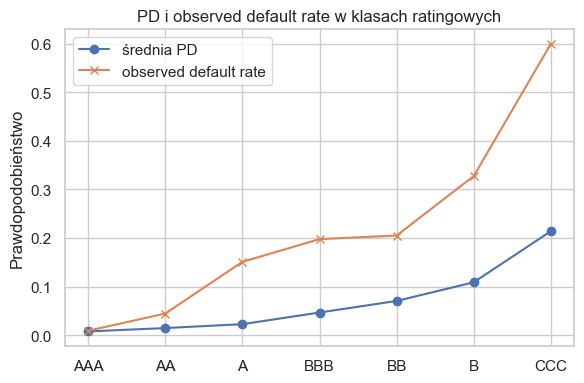

In [68]:
plt.figure(figsize=(6, 4))
plt.plot(rating_table["rating"], rating_table["mean_pd"], marker="o", label="średnia PD")
plt.plot(rating_table["rating"], rating_table["default_rate"], marker="x", label="observed default rate")
plt.ylabel("Prawdopodobieństwo")
plt.title("PD i observed default rate w klasach ratingowych")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
y_pred_opt = (p_test_4_arr >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred_opt).ravel()

print("Macierz pomyłek (po kalibracji 4% i progu optymalnym):")
print(confusion_matrix(y_test_arr, y_pred_opt))
print(f"TPR (recall defaultów): {tp / (tp + fn):.3f}")
print(f"FPR (fałszywe alarmy): {fp / (fp + tn):.3f}")
print(f"Udział zaakceptowanych (pred=0): {(tn + fn) / len(y_test_arr):.3f}")
print(f"Udział odrzuconych (pred=1): {(tp + fp) / len(y_test_arr):.3f}")

Macierz pomyłek (po kalibracji 4% i progu optymalnym):
[[243 141]
 [ 19  47]]
TPR (recall defaultów): 0.712
FPR (fałszywe alarmy): 0.367
Udział zaakceptowanych (pred=0): 0.582
Udział odrzuconych (pred=1): 0.418


## Porównanie modeli XGBoost vs Regresja logistyczna 

In [70]:
def model_metrics(y_true, p_pred, name="model"):
    """
    Funkcja licząca metryki
    """
    y_true = np.asarray(y_true).ravel()
    p_pred = np.asarray(p_pred).ravel()
    
    auc = roc_auc_score(y_true, p_pred)
    pr_auc = average_precision_score(y_true, p_pred)
    ll = log_loss(y_true, p_pred)
    brier = brier_score_loss(y_true, p_pred)
    ece = expected_calibration_error(y_true, p_pred)
    
    ks_stat, _ = ks_2samp(p_pred[y_true == 0], p_pred[y_true == 1])
    
    return {
        "model": name,
        "AUC": auc,
        "PR_AUC": pr_auc,
        "log_loss": ll,
        "Brier": brier,
        "ECE": ece,
        "KS": ks_stat
    }

In [71]:
# 1. Logit – niekalibrowany
p_logit = best_logit_pipe.predict_proba(X_test_final)[:, 1]

# 2. XGB – niekalibrowany
p_xgb = best_xgb_pipe.predict_proba(X_test_final)[:, 1]

# 3. Model z kalibracją 4%
p_calib4 = np.asarray(p_test_4).ravel()

y_true_final = np.asarray(y_test_final).ravel()

metrics_list = []
metrics_list.append(model_metrics(y_true_final, p_logit, name="Logit (raw)"))
metrics_list.append(model_metrics(y_true_final, p_xgb,   name="XGB (raw)"))
metrics_list.append(model_metrics(y_true_final, p_calib4, name="XGB (PD=4%)"))  # albo Logit (PD=4%)

metrics_df = pd.DataFrame(metrics_list)
metrics_df

,model,AUC,PR_AUC,log_loss,Brier,ECE,KS
0,Logit (raw),0.732560,0.316304,0.617028,0.213308,0.314670,0.351562
1,XGB (raw),0.750908,0.295070,0.371150,0.115903,0.042657,0.391572
2,XGB (PD=4%),0.743588,0.290126,0.464159,0.130143,0.134129,0.352983


In [72]:
def subgroup_metrics(df, y_col, p_col, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        m = model_metrics(sub[y_col], sub[p_col], name=str(g))
        m["group"] = g
        m["n"] = len(sub)
        m["mean_PD"] = sub[p_col].mean()
        m["default_rate"] = sub[y_col].mean()
        rows.append(m)
    return pd.DataFrame(rows)

In [73]:
df_test_final = X_test_final.copy()
df_test_final["y"] = y_true_final
df_test_final["PD_4"] = p_calib4

In [74]:
feature_seg = "Kapital_wlasny"

median_val = df_test_final[feature_seg].median()
df_test_final["segment"] = np.where(
    df_test_final[feature_seg] >= median_val,
    f"{feature_seg}_wysoki",
    f"{feature_seg}_niski"
)

subgroup_df = subgroup_metrics(
    df_test_final,
    y_col="y",
    p_col="PD_4",
    group_col="segment"
)

subgroup_df


,model,AUC,PR_AUC,log_loss,Brier,ECE,KS,group,n,mean_PD,default_rate
0,Kapital_wlasny_niski,0.641002,0.324907,0.653004,0.189827,0.167138,0.225881,Kapital_wlasny_niski,225,0.058785,0.217778
1,Kapital_wlasny_wysoki,0.805995,0.192078,0.275315,0.070458,0.081410,0.526584,Kapital_wlasny_wysoki,225,0.021216,0.075556
